## Recognising Disaster Tweets. 
#### Workflow:
- Load The Data. 
- EDA. 
- Preprocessing. 
- Feature Engineering. 
- Model Training and Evaluation. 
- improve the model (Trial and Error).
- Generate submission.csv
- Submit in Kaggle

## Load The Data

In [1]:
# --- import ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Explore

In [3]:
# --- Shape ---
print(f"Train Dataset Raw {train.shape[0]}, Column {train.shape[1]}")
print(f"Test Dataset Raw {test.shape[0]}, Column {test.shape[1]}")

Train Dataset Raw 7613, Column 5
Test Dataset Raw 3263, Column 4


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB


In [5]:
train.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


In [6]:
# --- % of Null --- 
(train.isnull().sum() / train.shape[0]) * 100

id           0.000000
keyword      0.801261
location    33.272035
text         0.000000
target       0.000000
dtype: float64

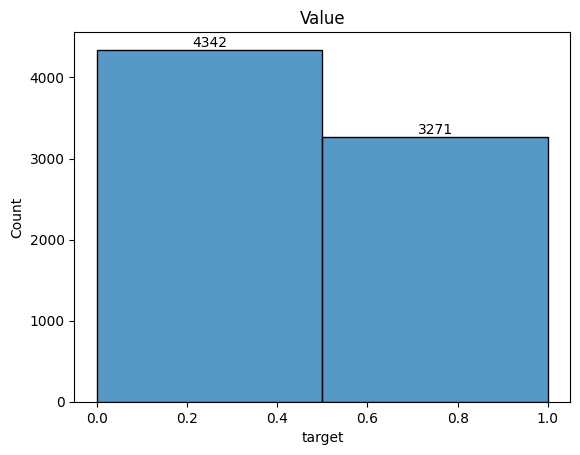

In [7]:
# --- Count of Target ---
ax = sns.histplot(data=train, x = 'target', bins = 2)
for i in ax.containers:
    ax.bar_label(i)
plt.title("Value")
plt.show()

In [8]:
train['length'] = train['text'].apply(lambda x: len(x))
train['length'].head(10)

0     69
1     38
2    133
3     65
4     88
5    110
6     95
7     59
8     79
9     52
Name: length, dtype: int64

In [9]:
# --- Count of Target vs Length of Tweet text ---
plt.show()

The length of Non Disaster Tweets is more than that of Disaster twits. 

Text(0.5, 1.0, 'Top 20 Keywords')

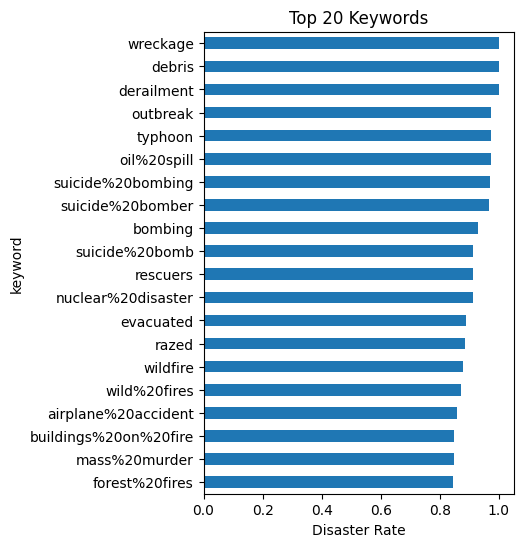

In [10]:
# --- Top 20 Keywords by Disaster Rate ---
keyword_rate = (train.groupby("keyword")["target"].mean().sort_values(ascending = False))
plt.figure(figsize = (4, 6))

keyword_rate.head(20).sort_values().plot(kind = "barh")
plt.xlabel("Disaster Rate")
plt.title("Top 20 Keywords")

In [11]:
train['word_length'] = train['text'].str.split().str.len()

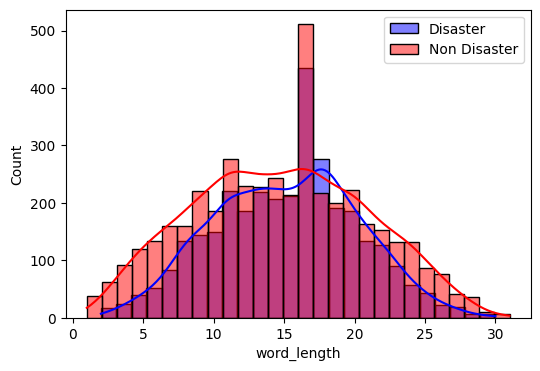

In [12]:
# --- tweet word number vs Disaster count ---
plt.figure(figsize = (6, 4))
sns.histplot(train[train['target'] == 1]['word_length'], color = 'blue', kde = True, label = 'Disaster')
sns.histplot(train[train['target'] == 0]['word_length'], color = 'red', kde = True, label = 'Non Disaster')
plt.legend()
plt.show()

<Axes: ylabel='location'>

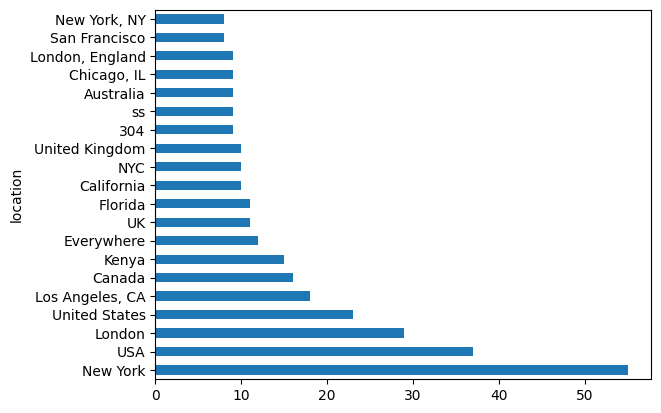

In [13]:
# --- Non Disaster Tweet locations Ranking ---
train[train['target'] == 0]['location'].value_counts().head(20).plot(kind = 'barh')

<Axes: ylabel='location'>

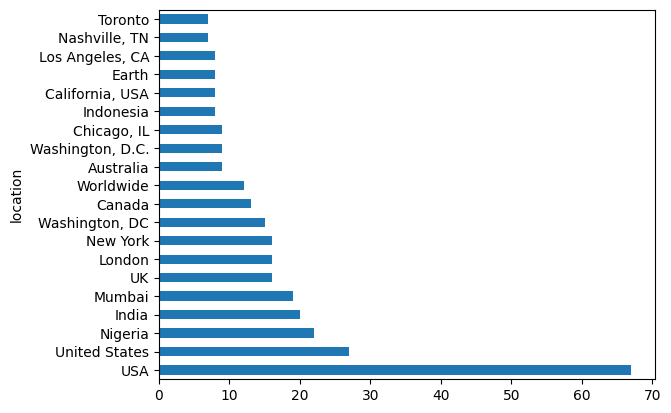

In [14]:
# --- Non Disaster Tweet locations Ranking ---
train[train['target'] == 1]['location'].value_counts().head(20).plot(kind = 'barh')

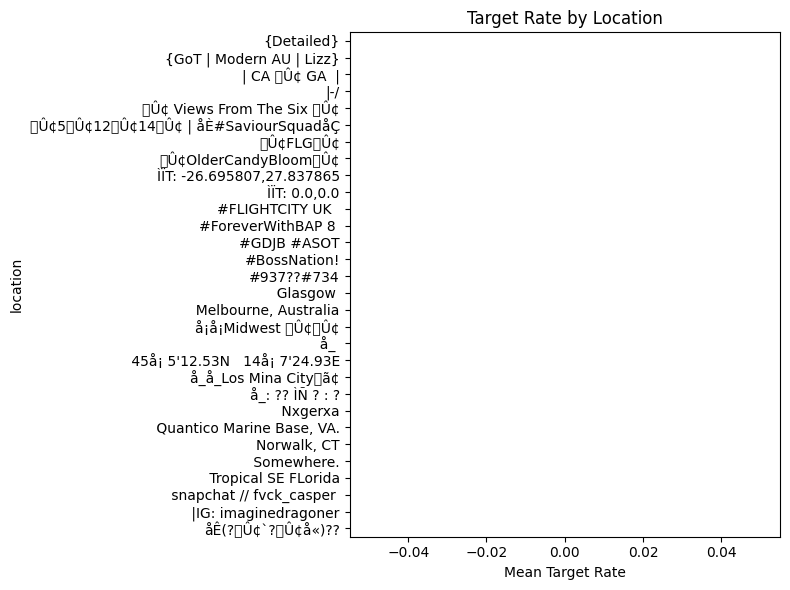

In [15]:
# --- Anomaly locations ---
import matplotlib as mpl
mpl.rcParams['text.parse_math'] = False

plt.figure(figsize = (3, 5))
location_rate = train.groupby('location')['target'].mean().sort_values(ascending=True).head(30)
location_rate.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Mean Target Rate')
plt.title('Target Rate by Location')
plt.tight_layout()
plt.show()

In [16]:
# --- Do Something About the NA values in Keywords and Locations ---
unique_locations = train['location'].dropna().str.strip().str.lower().unique()
unique_locations

<ArrowStringArray>
[                   'birmingham', 'est. september 2012 - bristol',
                        'africa',              'philadelphia, pa',
                    'london, uk',                      'pretoria',
                  'world wide!!',                'paranaque city',
                'live on webcam',                     'milky way',
 ...
              'milwaukee county',    'click the link below, okay',
             'probably not home',                             '6',
                  'at your back',                'livingston, mt',
                 'denton, texas',        '#newcastleupontyne #uk',
             'vancouver, canada',                       'lincoln']
Length: 3164, dtype: str

In [17]:
def add_location(raw):
    if pd.notna(raw['location']):
        return raw['location']
    text = str(raw['text']).lower()
    for loc in unique_locations:
        if str(loc).lower() in text:
            return loc
    return raw['location']

# --- Apply on train data, test data ---
train["location"] = train.apply(add_location, axis = 1)
test["location"] = test.apply(add_location, axis = 1)

In [18]:
test['location'].isnull().sum()

np.int64(0)

In [19]:
train['keyword'] = train['keyword'].fillna('unknown')
test['keyword'] = test['keyword'].fillna('unknown')

<Axes: >

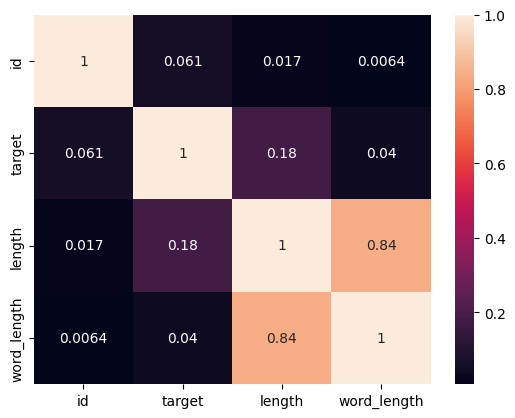

In [20]:
sns.heatmap(train.corr(numeric_only = True), annot = True)

## Preprocessing

In [21]:
import re
import nltk
from nltk.stem import PorterStemmer

from nltk.corpus import stopwords
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to C:\Users\Pranam
[nltk_data]     chand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Pranam
[nltk_data]     chand\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [22]:
# --- Text Cleaning ---
def text_cleaning(raw):
    raw["clean_text"] = raw["text"].str.lower()

    raw["clean_text"] = raw["clean_text"].apply(
        lambda x: re.sub(r"http\S+|www\S+|https\S+", "", x)
    )

    raw["clean_text"] = raw["clean_text"].str.replace(
        r"[^\w\s]", "", regex=True
    )

    raw["clean_text"] = raw["clean_text"].str.replace(
        r"\d+", "", regex=True
    )

    raw["clean_text"] = raw["clean_text"].str.strip()
    raw["clean_text"] = raw["clean_text"].str.replace(
        r"\s+", " ", regex=True
    )

    stop_words = set(stopwords.words("english"))

    def remove_stopwords(text):
        words = text.split()
        words = [word for word in words if word not in stop_words]
        return " ".join(words)

    raw["clean_text"] = raw["clean_text"].apply(remove_stopwords)

    stemmer = PorterStemmer()

    def stemming(text):
        words = text.split()
        words = [stemmer.stem(word) for word in words]
        return " ".join(words)

    raw["stemmed_text"] = raw["clean_text"].apply(stemming)

    return raw

In [23]:
train = text_cleaning(train)
test = text_cleaning(test)

In [24]:
# --- Model 1 ---
train['text_only'] = train['clean_text'].copy()
test['text_only'] = test['clean_text'].copy()

# --- Model 2 ---
train['text_keyword'] = train['clean_text'] + " " + train['keyword']
test['text_keyword'] = test['clean_text'] + " " + test['keyword']

# --- Model 3 ---
train["text_location"] = train["location"] + " " + train["clean_text"]
test["text_location"] = test["location"] + " " + test["clean_text"]

# --- Model 4 ---
train["text_keyword_location"] = train["keyword"] + " " + train["location"] + " " + train["clean_text"]
test["text_keyword_location"] = test["keyword"] + " " + test["location"] + " " + test["clean_text"]

In [25]:
train.columns

Index(['id', 'keyword', 'location', 'text', 'target', 'length', 'word_length',
       'clean_text', 'stemmed_text', 'text_only', 'text_keyword',
       'text_location', 'text_keyword_location'],
      dtype='str')

## Feature Engineering 

In [36]:
# --- import libraries ---
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [57]:
# --- splitting and Vectorisation ---
x = train['text_only']
y = train['target']

x_train, x_valid, y_train, y_valid = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y)
vectorizer  = TfidfVectorizer( max_features=7000,
                                ngram_range=(1, 2), stop_words = "english")


x_train_vec = vectorizer.fit_transform(x_train)
x_valid_vec = vectorizer.transform(x_valid)

## Model Training and Evaluation.
##### I am going to use Logistic Regression, Random Forest, Linear SVC, Multinomial Naive Bayes and XGBoost. (chatGPT suggested)

In [58]:
# --- Import Libraries ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

In [59]:
print('Model 1 only_text')

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),
    "Linear SVC": LinearSVC(
        random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():
    print("=" * 70)
    print(name)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(x_valid_vec)

    # Metrics
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Model 1 only_text
Logistic Regression
Accuracy : 0.8155
Precision: 0.8373
Recall   : 0.7080
F1 Score : 0.7672
Linear SVC
Accuracy : 0.7873
Precision: 0.7696
Recall   : 0.7202
F1 Score : 0.7441
Multinomial Naive Bayes
Accuracy : 0.8070
Precision: 0.8543
Recall   : 0.6636
F1 Score : 0.7470
Random Forest
Accuracy : 0.7945
Precision: 0.7965
Recall   : 0.7003
F1 Score : 0.7453
XGBoost
Accuracy : 0.7768
Precision: 0.8458
Recall   : 0.5872
F1 Score : 0.6931


In [60]:
# --- splitting and Vectorisation ---
x = train['text_keyword']
y = train['target']

x_train, x_valid, y_train, y_valid = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y)
vectorizer  = TfidfVectorizer( max_features=7000,
                                ngram_range=(1, 2), stop_words = "english")


x_train_vec = vectorizer.fit_transform(x_train)
x_valid_vec = vectorizer.transform(x_valid)

In [62]:
print('Model 2 text_keyword')

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),
    "Linear SVC": LinearSVC(
        random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():
    print("=" * 70)
    print(name)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(x_valid_vec)

    # Metrics
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Model 1 text_keyword
Logistic Regression
Accuracy : 0.5588
Precision: 0.4628
Recall   : 0.1713
F1 Score : 0.2500
Linear SVC
Accuracy : 0.5292
Precision: 0.4308
Recall   : 0.2997
F1 Score : 0.3535
Multinomial Naive Bayes
Accuracy : 0.5286
Precision: 0.4431
Recall   : 0.3807
F1 Score : 0.4095
Random Forest
Accuracy : 0.5877
Precision: 0.5551
Recall   : 0.2003
F1 Score : 0.2944
XGBoost
Accuracy : 0.5699
Precision: 0.4945
Recall   : 0.0688
F1 Score : 0.1208


In [63]:
# --- splitting and Vectorisation ---
x = train['text_location']
y = train['target']

x_train, x_valid, y_train, y_valid = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y)
vectorizer  = TfidfVectorizer( max_features=7000,
                                ngram_range=(1, 2), stop_words = "english")


x_train_vec = vectorizer.fit_transform(x_train)
x_valid_vec = vectorizer.transform(x_valid)

In [65]:
print('Model 3 text_location')

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),
    "Linear SVC": LinearSVC(
        random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():
    print("=" * 70)
    print(name)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(x_valid_vec)

    # Metrics
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Model 3 text_location
Logistic Regression
Accuracy : 0.5279
Precision: 0.3883
Recall   : 0.1728
F1 Score : 0.2392
Linear SVC
Accuracy : 0.5233
Precision: 0.4333
Recall   : 0.3578
F1 Score : 0.3920
Multinomial Naive Bayes
Accuracy : 0.4846
Precision: 0.3931
Recall   : 0.3685
F1 Score : 0.3804
Random Forest
Accuracy : 0.5607
Precision: 0.4759
Recall   : 0.2263
F1 Score : 0.3067
XGBoost
Accuracy : 0.5424
Precision: 0.3252
Recall   : 0.0612
F1 Score : 0.1030


In [66]:
# --- splitting and Vectorisation ---
x = train['text_keyword_location']
y = train['target']

x_train, x_valid, y_train, y_valid = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y)
vectorizer  = TfidfVectorizer( max_features=7000,
                                ngram_range=(1, 2), stop_words = "english")


x_train_vec = vectorizer.fit_transform(x_train)
x_valid_vec = vectorizer.transform(x_valid)

In [67]:
print('Model 4 text_keyword_location')

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),
    "Linear SVC": LinearSVC(
        random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():
    print("=" * 70)
    print(name)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(x_valid_vec)

    # Metrics
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Model 4 text_keyword_location
Logistic Regression
Accuracy : 0.5640
Precision: 0.4839
Recall   : 0.2294
F1 Score : 0.3112
Linear SVC
Accuracy : 0.5358
Precision: 0.4545
Recall   : 0.4052
F1 Score : 0.4285
Multinomial Naive Bayes
Accuracy : 0.5378
Precision: 0.4618
Recall   : 0.4618
F1 Score : 0.4618
Random Forest
Accuracy : 0.5785
Precision: 0.5181
Recall   : 0.2630
F1 Score : 0.3489
XGBoost
Accuracy : 0.5706
Precision: 0.5000
Recall   : 0.0856
F1 Score : 0.1462


Of all the models, Model 1 (only_text) and Logistic Regression perform the best. 

# improve the model (Trial and Error)

In [70]:
# --- make the final model ---

x = train['text_only']
y = train['target']

x_train, x_valid, y_train, y_valid = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y)
vectorizer  = TfidfVectorizer( max_features=7000,
                                ngram_range=(1, 2), stop_words = "english")


x_train_vec = vectorizer.fit_transform(x_train)
x_valid_vec = vectorizer.transform(x_valid)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train_vec, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [72]:
# --- Calculate Accuracy and f1 ---
y_pred = lr.predict(x_valid_vec)

accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8155
Precision: 0.8373
Recall   : 0.7080
F1 Score : 0.7672


In [90]:
# --- Hyperparameter tuning ---
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [1, 10, 100],
    "solver": ["liblinear", "lbfgs", "saga"],
    "penalty": ["l2", 'deprecated'],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train_vec, y_train)

# Best Model
print("Best Parameters :", grid.best_params_)
print("Best F1 Score   :", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters : {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score   : 0.7433559727049951


In [91]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_valid_vec)
print("Validation F1 Score :", f1_score(y_valid, y_pred))

Validation F1 Score : 0.7665130568356375


The initial model is better, so we are going to use that

## Generate submission.csv

In [99]:
# --- predict target feature on test Data ---
X_test = test["text_only"]
X_test_vec = vectorizer.transform(X_test)
predictions = lr.predict(X_test_vec)

In [102]:
# --- making submission Dataframe --- 
submission = pd.DataFrame({
    "id": test["id"],
    "target": predictions
})

In [103]:
# --- save submission.csv --- 
submission.to_csv("submission.csv", index=False)